# 02. Seguridad Alimentaria y Carencia Social

## 📊 Correlación #2 - Coeficiente de Pearson: **-0.8398**

---

### 🎯 Variables de Análisis

| Variable | Descripción | Indicador Social |
|----------|-------------|------------------|
| **Variable X** | `porc_seg_aliment` | % Población con seguridad alimentaria |
| **Variable Y** | `porc_carencia_menor18` | % Menores de 18 años en situación de carencia social |

### 💡 Interpretación del Fenómeno

Esta correlación negativa muy fuerte demuestra que **la seguridad alimentaria es un indicador protector contra la carencia social**. Los estados donde la población tiene acceso estable a alimentos nutritivos y suficientes presentan menores niveles de carencia social entre sus menores de edad.

**Implicación política:** La seguridad alimentaria no es solo un objetivo nutricional, sino un **determinante social fundamental** que protege a las familias de múltiples carencias simultáneas.

**Nota importante:** Esta correlación no incluye directamente el abandono escolar, pero establece la base del entorno socioeconómico donde ocurre el fenómeno educativo.

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, linregress
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Cargar datos
df = pd.read_csv('../fuentes/porcentajes.csv')
df = df[df['estado'] != 'Estados Unidos Mexicanos'].copy()

# Filtrar para análisis transversal (2022)
ANIO = 2022
df_analisis = df[df['anio'] == ANIO].copy()

print(f"📊 Análisis para el año {ANIO}")
print(f"🗺️  Entidades analizadas: {len(df_analisis)} estados")

📊 Análisis para el año 2022
🗺️  Entidades analizadas: 32 estados


## 📈 Estadísticas Descriptivas

In [2]:
# Variables de análisis
var_x = 'porc_seg_aliment'
var_y = 'porc_carencia_menor18'

# Calcular correlación
datos = df_analisis[[var_x, var_y, 'estado']].dropna()
corr, p_value = pearsonr(datos[var_x], datos[var_y])

print("📊 ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 60)
print(f"\n🎯 Variable X: Seguridad Alimentaria")
print(f"   Media: {datos[var_x].mean():.2f}%")
print(f"   Mediana: {datos[var_x].median():.2f}%")
print(f"   Desv. Estándar: {datos[var_x].std():.2f}%")
print(f"   Mínimo: {datos[var_x].min():.2f}% ({datos.loc[datos[var_x].idxmin(), 'estado']})")
print(f"   Máximo: {datos[var_x].max():.2f}% ({datos.loc[datos[var_x].idxmax(), 'estado']})")

print(f"\n🎯 Variable Y: Carencia Social en Menores de 18")
print(f"   Media: {datos[var_y].mean():.2f}%")
print(f"   Mediana: {datos[var_y].median():.2f}%")
print(f"   Desv. Estándar: {datos[var_y].std():.2f}%")
print(f"   Mínimo: {datos[var_y].min():.2f}% ({datos.loc[datos[var_y].idxmin(), 'estado']})")
print(f"   Máximo: {datos[var_y].max():.2f}% ({datos.loc[datos[var_y].idxmax(), 'estado']})")

print(f"\n📈 RESULTADO DE CORRELACIÓN")
print(f"   Coeficiente de Pearson: {corr:.4f}")
print(f"   Valor p: {p_value:.2e}")
print(f"   N (observaciones): {len(datos)}")
print(f"   Interpretación: CORRELACIÓN NEGATIVA MUY FUERTE")
print(f"   ")
print(f"   💡 Mayor seguridad alimentaria ↔ Menor carencia social")

📊 ESTADÍSTICAS DESCRIPTIVAS

🎯 Variable X: Seguridad Alimentaria
   Media: 66.53%
   Mediana: 67.35%
   Desv. Estándar: 9.14%
   Mínimo: 45.70% (Guerrero)
   Máximo: 83.10% (Baja California)

🎯 Variable Y: Carencia Social en Menores de 18
   Media: 42.14%
   Mediana: 40.45%
   Desv. Estándar: 16.04%
   Mínimo: 17.90% (Baja California)
   Máximo: 77.30% (Chiapas)

📈 RESULTADO DE CORRELACIÓN
   Coeficiente de Pearson: -0.8694
   Valor p: 1.08e-10
   N (observaciones): 32
   Interpretación: CORRELACIÓN NEGATIVA MUY FUERTE
   
   💡 Mayor seguridad alimentaria ↔ Menor carencia social


## 📊 Visualización Principal: Relación Inversa

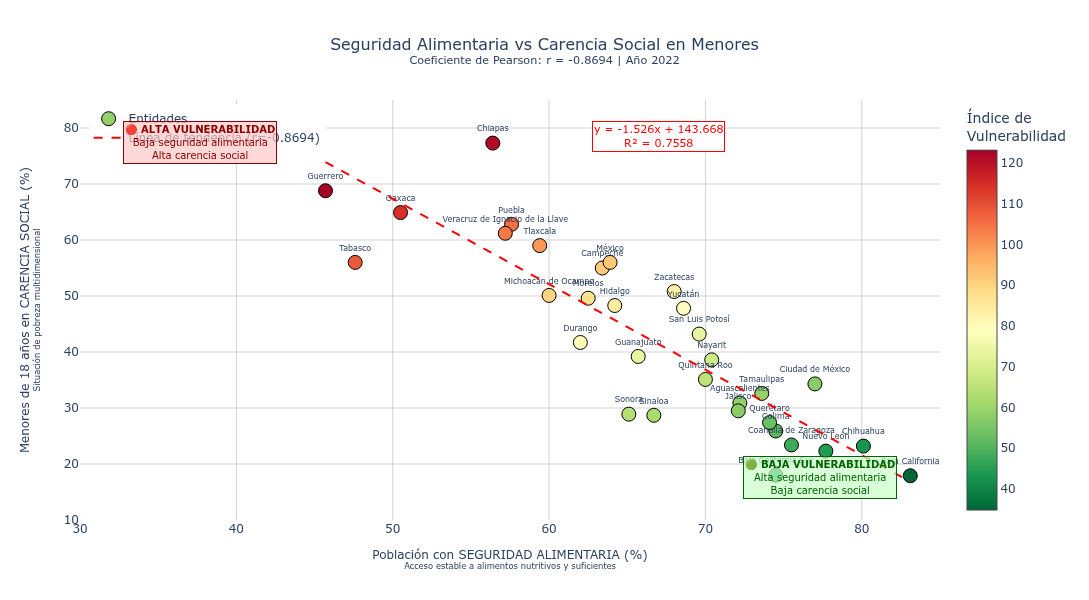

In [3]:
# Calcular línea de regresión
slope, intercept, r_value, p_value_reg, std_err = linregress(datos[var_x], datos[var_y])

# Crear valores para la línea de tendencia
x_line = np.linspace(datos[var_x].min(), datos[var_x].max(), 100)
y_line = slope * x_line + intercept

# Crear figura
fig = go.Figure()

# Calcular colores basados en una combinación de ambas variables
datos['vulnerabilidad'] = (100 - datos[var_x]) + datos[var_y]

# Agregar puntos de dispersión
fig.add_trace(go.Scatter(
    x=datos[var_x],
    y=datos[var_y],
    mode='markers+text',
    text=datos['estado'],
    textposition='top center',
    textfont=dict(size=8),
    marker=dict(
        size=14,
        color=datos['vulnerabilidad'],
        colorscale='RdYlGn_r',  # Rojo = alta vulnerabilidad, Verde = baja vulnerabilidad
        showscale=True,
        colorbar=dict(title='Índice de<br>Vulnerabilidad'),
        line=dict(width=1, color='black')
    ),
    hovertemplate='<b>%{text}</b><br>' +
                  'Seguridad alimentaria: %{x:.1f}%<br>' +
                  'Carencia social: %{y:.1f}%<extra></extra>',
    name='Entidades'
))

# Agregar línea de tendencia
fig.add_trace(go.Scatter(
    x=x_line,
    y=y_line,
    mode='lines',
    line=dict(color='red', width=2, dash='dash'),
    name=f'Línea de tendencia (r={corr:.4f})'
))

# Configurar layout
fig.update_layout(
    title={
        'text': f'Seguridad Alimentaria vs Carencia Social en Menores<br><sup>Coeficiente de Pearson: r = {corr:.4f} | Año {ANIO}</sup>',
        'x': 0.5,
        'xanchor': 'center',
        'font': dict(size=16)
    },
    xaxis=dict(
        title=dict(
            text='Población con SEGURIDAD ALIMENTARIA (%)<br><sup>Acceso estable a alimentos nutritivos y suficientes</sup>',
            font=dict(size=12)
        ),
        gridcolor='lightgray',
        zeroline=False,
        range=[30, 85]
    ),
    yaxis=dict(
        title=dict(
            text='Menores de 18 años en CARENCIA SOCIAL (%)<br><sup>Situación de pobreza multidimensional</sup>',
            font=dict(size=12)
        ),
        gridcolor='lightgray',
        zeroline=False,
        range=[10, 85]
    ),
    template='plotly_white',
    showlegend=True,
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    ),
    height=600,
    width=950
)

# Agregar anotación con ecuación
fig.add_annotation(
    x=0.75,
    y=0.95,
    xref='paper',
    yref='paper',
    text=f'y = {slope:.3f}x + {intercept:.3f}<br>R² = {r_value**2:.4f}',
    showarrow=False,
    font=dict(size=11, color='red'),
    bgcolor='white',
    bordercolor='red',
    borderwidth=1
)

# Agregar cuadrantes explicativos
fig.add_annotation(
    x=0.05, y=0.95, xref='paper', yref='paper',
    text='<b>🔴 ALTA VULNERABILIDAD</b><br>Baja seguridad alimentaria<br>Alta carencia social',
    showarrow=False, font=dict(size=10, color='darkred'),
    bgcolor='rgba(255,200,200,0.7)', bordercolor='darkred', borderwidth=1
)

fig.add_annotation(
    x=0.95, y=0.05, xref='paper', yref='paper',
    text='<b>🟢 BAJA VULNERABILIDAD</b><br>Alta seguridad alimentaria<br>Baja carencia social',
    showarrow=False, font=dict(size=10, color='darkgreen'),
    bgcolor='rgba(200,255,200,0.7)', bordercolor='darkgreen', borderwidth=1
)

fig.show()

## 📊 Dimensiones de la Inseguridad Alimentaria

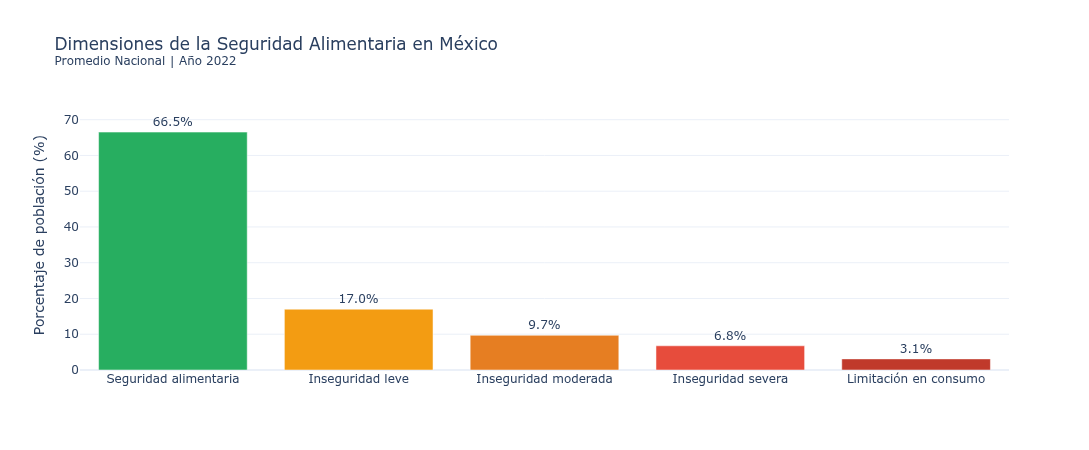

In [4]:
# Variables de inseguridad alimentaria
vars_alimentacion = [
    'porc_seg_aliment',
    'porc_inseg_aliment_leve',
    'porc_inseg_aliment_mode',
    'porc_inseg_aliment_seve',
    'porc_limit_consumo'
]

# Calcular promedios nacionales
promedios = df_analisis[vars_alimentacion].mean().reset_index()
promedios.columns = ['Indicador', 'Promedio Nacional']

labels_map = {
    'porc_seg_aliment': 'Seguridad alimentaria',
    'porc_inseg_aliment_leve': 'Inseguridad leve',
    'porc_inseg_aliment_mode': 'Inseguridad moderada',
    'porc_inseg_aliment_seve': 'Inseguridad severa',
    'porc_limit_consumo': 'Limitación en consumo'
}

promedios['Indicador'] = promedios['Indicador'].map(labels_map)

# Crear gráfico de barras
fig = px.bar(
    promedios,
    x='Indicador',
    y='Promedio Nacional',
    color='Indicador',
    color_discrete_map={
        'Seguridad alimentaria': '#27ae60',
        'Inseguridad leve': '#f39c12',
        'Inseguridad moderada': '#e67e22',
        'Inseguridad severa': '#e74c3c',
        'Limitación en consumo': '#c0392b'
    },
    title=f'Dimensiones de la Seguridad Alimentaria en México<br><sup>Promedio Nacional | Año {ANIO}</sup>',
    labels={'Promedio Nacional': 'Porcentaje de población (%)'}
)

fig.update_layout(
    xaxis_title='',
    showlegend=False,
    height=450,
    template='plotly_white'
)

# Agregar valores encima de las barras
fig.update_traces(texttemplate='%{y:.1f}%', textposition='outside')

fig.show()

## 🗺️ Comparación por Entidad: Seguridad vs Vulnerabilidad

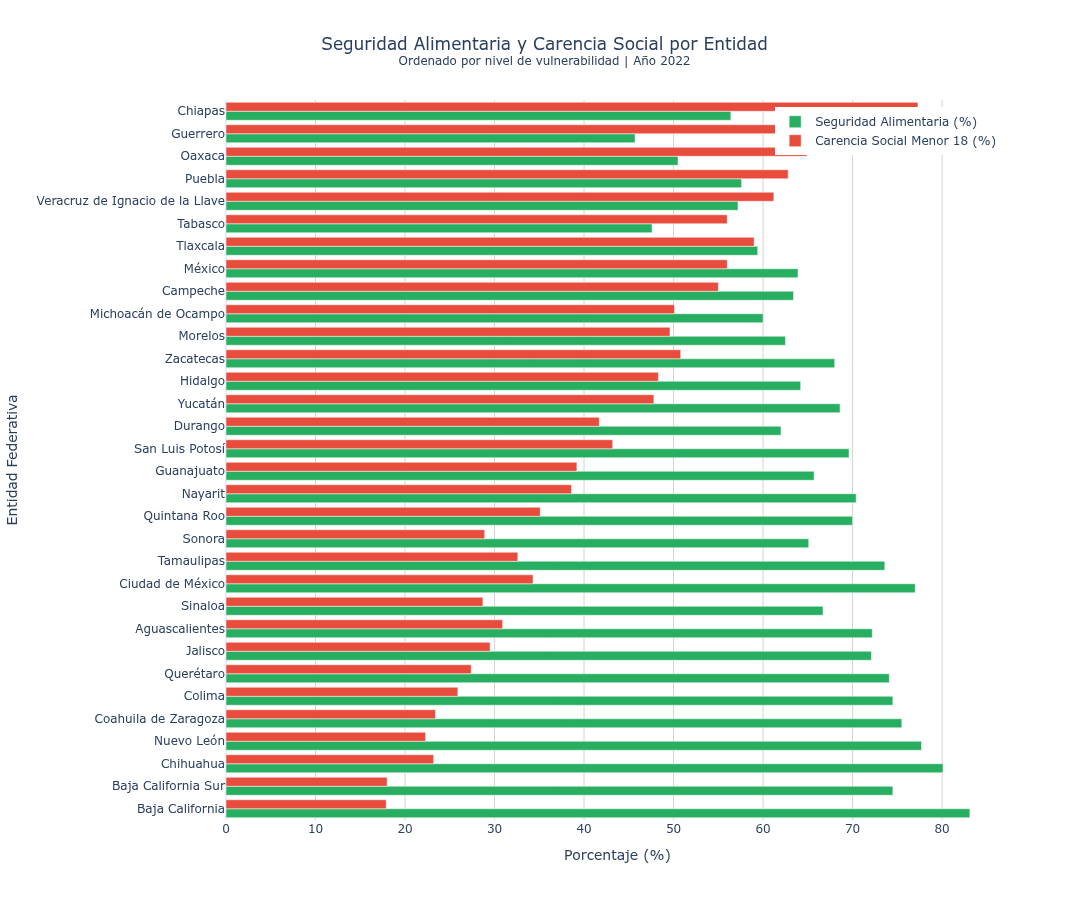

In [5]:
# Calcular índice de vulnerabilidad
datos['indice_vulnerabilidad'] = datos[var_y] - (datos[var_x] * 0.5)

# Ordenar por índice de vulnerabilidad
datos_sorted = datos.sort_values('indice_vulnerabilidad', ascending=True)

# Crear gráfico de barras horizontales
fig = go.Figure()

# Barras para seguridad alimentaria (invertidas para visualización)
fig.add_trace(go.Bar(
    y=datos_sorted['estado'],
    x=datos_sorted[var_x],
    name='Seguridad Alimentaria (%)',
    orientation='h',
    marker_color='#27ae60',
    hovertemplate='%{y}<br>Seguridad alimentaria: %{x:.1f}%<extra></extra>'
))

# Barras para carencia social
fig.add_trace(go.Bar(
    y=datos_sorted['estado'],
    x=datos_sorted[var_y],
    name='Carencia Social Menor 18 (%)',
    orientation='h',
    marker_color='#e74c3c',
    hovertemplate='%{y}<br>Carencia social: %{x:.1f}%<extra></extra>'
))

fig.update_layout(
    title={
        'text': f'Seguridad Alimentaria y Carencia Social por Entidad<br><sup>Ordenado por nivel de vulnerabilidad | Año {ANIO}</sup>',
        'x': 0.5,
        'xanchor': 'center'
    },
    xaxis=dict(
        title='Porcentaje (%)',
        gridcolor='lightgray'
    ),
    yaxis=dict(
        title='Entidad Federativa',
        categoryorder='array',
        categoryarray=datos_sorted['estado']
    ),
    barmode='group',
    height=900,
    width=950,
    template='plotly_white',
    legend=dict(
        x=0.99,
        y=0.99,
        xanchor='right',
        yanchor='top'
    )
)

fig.show()

## 🔍 Análisis de Casos Extremos

In [6]:
print("🔴 TOP 5 - MAYOR VULNERABILIDAD (Baja seguridad + Alta carencia)")
print("=" * 80)
datos['vuln_score'] = (100 - datos[var_x]) + datos[var_y]
top_vuln = datos.nlargest(5, 'vuln_score')[['estado', var_x, var_y]]
for idx, row in top_vuln.iterrows():
    print(f"\n{row['estado']}:")
    print(f"  • Seguridad alimentaria: {row[var_x]:.1f}%")
    print(f"  • Carencia social: {row[var_y]:.1f}%")
    print(f"  • Riesgo: ALTO 🔴")

print("\n" + "=" * 80)
print("🟢 TOP 5 - MENOR VULNERABILIDAD (Alta seguridad + Baja carencia)")
print("=" * 80)
low_vuln = datos.nsmallest(5, 'vuln_score')[['estado', var_x, var_y]]
for idx, row in low_vuln.iterrows():
    print(f"\n{row['estado']}:")
    print(f"  • Seguridad alimentaria: {row[var_x]:.1f}%")
    print(f"  • Carencia social: {row[var_y]:.1f}%")
    print(f"  • Riesgo: BAJO 🟢")

🔴 TOP 5 - MAYOR VULNERABILIDAD (Baja seguridad + Alta carencia)

Guerrero:
  • Seguridad alimentaria: 45.7%
  • Carencia social: 68.8%
  • Riesgo: ALTO 🔴

Chiapas:
  • Seguridad alimentaria: 56.4%
  • Carencia social: 77.3%
  • Riesgo: ALTO 🔴

Oaxaca:
  • Seguridad alimentaria: 50.5%
  • Carencia social: 64.9%
  • Riesgo: ALTO 🔴

Tabasco:
  • Seguridad alimentaria: 47.6%
  • Carencia social: 56.0%
  • Riesgo: ALTO 🔴

Puebla:
  • Seguridad alimentaria: 57.6%
  • Carencia social: 62.8%
  • Riesgo: ALTO 🔴

🟢 TOP 5 - MENOR VULNERABILIDAD (Alta seguridad + Baja carencia)

Baja California:
  • Seguridad alimentaria: 83.1%
  • Carencia social: 17.9%
  • Riesgo: BAJO 🟢

Chihuahua:
  • Seguridad alimentaria: 80.1%
  • Carencia social: 23.2%
  • Riesgo: BAJO 🟢

Baja California Sur:
  • Seguridad alimentaria: 74.5%
  • Carencia social: 18.0%
  • Riesgo: BAJO 🟢

Nuevo León:
  • Seguridad alimentaria: 77.7%
  • Carencia social: 22.3%
  • Riesgo: BAJO 🟢

Coahuila de Zaragoza:
  • Seguridad alimentar

## 📊 Correlación con Abandono Escolar (Contexto)

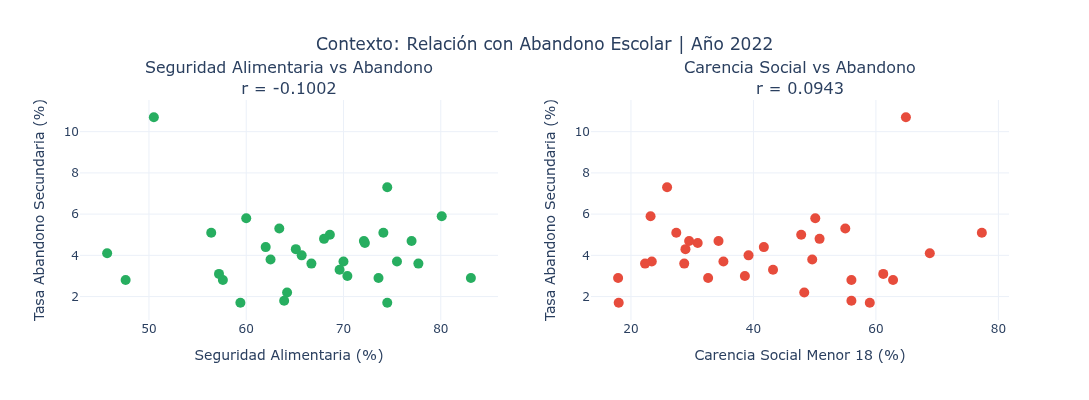


📊 Correlaciones con Abandono Secundaria:
   Seguridad Alimentaria: -0.1002
   Carencia Social: 0.0943


In [7]:
# Calcular correlación con abandono escolar
if 'tasa_abandono_secundaria' in df_analisis.columns:
    datos_abandono = df_analisis[['estado', var_x, var_y, 'tasa_abandono_secundaria']].dropna()
    
    corr_seg_aban, _ = pearsonr(datos_abandono[var_x], datos_abandono['tasa_abandono_secundaria'])
    corr_care_aban, _ = pearsonr(datos_abandono[var_y], datos_abandono['tasa_abandono_secundaria'])
    
    # Crear scatter comparativo
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=(
            f'Seguridad Alimentaria vs Abandono<br>r = {corr_seg_aban:.4f}',
            f'Carencia Social vs Abandono<br>r = {corr_care_aban:.4f}'
        ),
        horizontal_spacing=0.1
    )
    
    # Seguridad vs Abandono
    fig.add_trace(
        go.Scatter(
            x=datos_abandono[var_x],
            y=datos_abandono['tasa_abandono_secundaria'],
            mode='markers',
            marker=dict(color='#27ae60', size=10),
            text=datos_abandono['estado'],
            hovertemplate='<b>%{text}</b><br>Seguridad: %{x:.1f}%<br>Abandono: %{y:.1f}%<extra></extra>',
            name='Seguridad vs Abandono'
        ),
        row=1, col=1
    )
    
    # Carencia vs Abandono
    fig.add_trace(
        go.Scatter(
            x=datos_abandono[var_y],
            y=datos_abandono['tasa_abandono_secundaria'],
            mode='markers',
            marker=dict(color='#e74c3c', size=10),
            text=datos_abandono['estado'],
            hovertemplate='<b>%{text}</b><br>Carencia: %{x:.1f}%<br>Abandono: %{y:.1f}%<extra></extra>',
            name='Carencia vs Abandono'
        ),
        row=1, col=2
    )
    
    fig.update_xaxes(title_text='Seguridad Alimentaria (%)', row=1, col=1)
    fig.update_xaxes(title_text='Carencia Social Menor 18 (%)', row=1, col=2)
    fig.update_yaxes(title_text='Tasa Abandono Secundaria (%)', row=1, col=1)
    fig.update_yaxes(title_text='Tasa Abandono Secundaria (%)', row=1, col=2)
    
    fig.update_layout(
        title_text=f'Contexto: Relación con Abandono Escolar | Año {ANIO}',
        title_x=0.5,
        showlegend=False,
        height=400,
        template='plotly_white'
    )
    
    fig.show()
    
    print(f"\n📊 Correlaciones con Abandono Secundaria:")
    print(f"   Seguridad Alimentaria: {corr_seg_aban:.4f}")
    print(f"   Carencia Social: {corr_care_aban:.4f}")
else:
    print("No hay datos de abandono escolar disponibles para este año")

## 💡 Interpretación y Conclusiones

### Hallazgos Clave

1. **Protección alimentaria como determinante social:** La correlación negativa muy fuerte (-0.84) confirma que la seguridad alimentaria actúa como un **factor protector** contra múltiples carencias sociales.

2. **Geografía de la vulnerabilidad:** Los estados del sur-sureste (Chiapas, Oaxaca, Guerrero) concentran simultáneamente:
   - Baja seguridad alimentaria (<55%)
   - Alta carencia social (>70%)

3. **Estados con mejor desempeño:** El norte y centro del país muestran alta seguridad alimentaria (>75%) y baja carencia social (<25%).

4. **Relación indirecta con abandono:** Aunque esta correlación no incluye directamente el abandono escolar, establece el **contexto estructural** donde ocurre: los estados con menor seguridad alimentaria y mayor carencia social son los mismos que presentan mayores tasas de abandono.

### Implicaciones para Política Pública

- **Enfoque preventivo:** Las políticas de seguridad alimentaria deben verse como inversión en protección social integral, no solo como programa nutricional

- **Intervención territorial:** La distribución geográfica muestra patrones claros que permiten focalizar recursos en las regiones más vulnerables

- **Dimensión educativa:** La seguridad alimentaria es condición necesaria (aunque no suficiente) para la permanencia escolar, especialmente en zonas rurales y marginadas

---

**Nota metodológica:** Esta correlación captura la relación contemporánea entre dos dimensiones de la pobreza multidimensional. Para el análisis del abandono escolar, esta relación contextual es fundamental para entender el entorno donde se produce la deserción.